In [ ]:
#NLP sobre IMDB Dataset of 50K Movie Reviews
#https://www.kaggle.com/datasets/luisdiegofv97/imdb-dataset-of-50k-movie-reviews-spanish?resource=download#

import pandas as pd
import csv  # Importar el módulo csv

#importing dataset
# Usar on_bad_lines para manejar líneas mal formadas
df = pd.read_csv('IMDB Dataset SPANISH.csv', delimiter=',', quotechar='"', on_bad_lines='skip', encoding='utf-8', engine='python')
print(df.head())

   Unnamed: 0                                          review_en  \
0           0  One of the other reviewers has mentioned that ...   
1           1  A wonderful little production. The filming tec...   
2           2  I thought this was a wonderful way to spend ti...   
3           3  Basically there's a family where a little boy ...   
4           4  Petter Mattei's "Love in the Time of Money" is...   

                                           review_es sentiment sentimiento  
0  Uno de los otros críticos ha mencionado que de...  positive    positivo  
1  Una pequeña pequeña producción.La técnica de f...  positive    positivo  
2  Pensé que esta era una manera maravillosa de p...  positive    positivo  
3  Básicamente, hay una familia donde un niño peq...  negative    negativo  
4  El "amor en el tiempo" de Petter Mattei es una...  positive    positivo  


In [ ]:
#Checking Dataset Description
print(df.describe())

         Unnamed: 0
count  41693.000000
mean   20846.000000
std    12035.876723
min        0.000000
25%    10423.000000
50%    20846.000000
75%    31269.000000
max    41692.000000


In [ ]:
#Sentiment count
print("Total :\n",df['sentimiento'].value_counts())

Total :
 sentimiento
negativo    20854
positivo    20839
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'review_en', 'review_es', 'sentiment', 'sentimiento'], dtype='object')


In [ ]:
review = []
sentences = list(df['review_es'])
for sen in sentences:
    review.append(sen)

In [ ]:
#Creación de etiquetas
import numpy as np

labels = df['sentimiento']
labels = np.array(list(map(lambda x: 1 if x=="positivo" else 0, labels)))

In [ ]:
#División de datos de entrenamiento y prueba

from sklearn.model_selection import train_test_split

train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20, random_state=42)

In [ ]:
# Preparar los datos
from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.2)

In [ ]:
# Número de ejemplos a visualizar
n_samples = 5

# Mostrar algunos ejemplos del conjunto de entrenamiento
for i in range(n_samples):
    print(f"Review: {train_sentences[i]}")
    print(f"Label: {train_labels[i]}")
    print("-" * 50)

Review: Incluso como un gran fan del género de terror bajo o bajo presupuesto, no pude encontrar este desastre ligeramente divertido.Con horrible actuación, una "parcela" dolorosa genérica y sin caracteres dimensionales, sin importar cuán aburridos y borrachos sean, este no vale la pena de sus 81 minutos.No cometas el mismo error que hice.Alquilar algo mas¡¡¡Algo más!!!
Label: 0
--------------------------------------------------
Review: Cuando encontré esta película en mi videostore local, esperaba que fuera otra película de vampiros de Cheesy American en la misma vena de "The Lost Boys" (1987). Para mi sorpresa "para morirse" es una muy buena película. Es un poco bueno.A veces, en los momentos, pero aún así hay suficientes piezas con estilo elegante y sorpresas para satisfacer a los entusiastas de los vampiros. Esta es una combinación perfecta de romance y horror y es sorprendentemente espantosamente a veces.
Label: 1
--------------------------------------------------
Review: Entreten

In [ ]:
# Parámetros de configuración
vocab_size = 10000
max_length = 120
embedding_dim = 16
trunc_type='post'
oov_tok = "<OOV>"

In [ ]:
pip install tensorflow

In [ ]:
#tokenización y acolchado de secuencias

import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#initialize the tokenizer class
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)

#Generate the word index dictionary for the training sentences
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index

#Generate and pad the training sequences
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences,maxlen=max_length, truncating=trunc_type)

#Generate and pad the test sequences
test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences,maxlen=max_length, truncating=trunc_type)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Flatten, Dense

#Construcción del modelo
model = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(64, return_sequences=True),
    LSTM(32),
   #Flatten(),
    Dense(64, activation='relu'), #Se ajustó de 6 a 64
    Dense(1, activation='sigmoid')
])

In [ ]:
#Construcción y entrenamiento del modelo
#setup the training parameters
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

# Print the model summary
print(model.summary())


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 143s 133ms/step - accuracy: 0.6243 - loss: 0.6286 - val_accuracy: 0.7952 - val_loss: 0.4370
Epoch 2/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - accuracy: 0.8419 - loss: 0.3746 - val_accuracy: 0.8220 - val_loss: 0.4299
Epoch 3/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 139s 130ms/step - accuracy: 0.8769 - loss: 0.3091 - val_accuracy: 0.8282 - val_loss: 0.3935
Epoch 4/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 136s 130ms/step - accuracy: 0.9000 - loss: 0.2598 - val_accuracy: 0.8244 - val_loss: 0.4189
Epoch 5/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 146s 134ms/step - accuracy: 0.9201 - loss: 0.2155 - val_accuracy: 0.8240 - val_loss: 0.4842
Epoch 6/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 145s 137ms/step - accuracy: 0.9424 - loss: 0.1640 - val_accuracy: 0.7977 - val_loss: 0.5275
Epoch 7/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 139s 133ms/step - accuracy: 0.9572 - loss: 0.1308 - val_accuracy: 0.8036 - val_loss: 0.6056
Epoch 8/10
1043/1043 ━━━━━━━━━━━━━━━━━━━━ 144s 138ms/step - ac

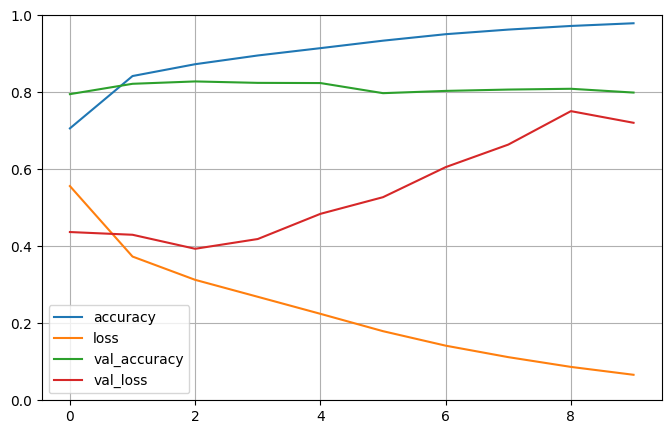

In [ ]:
#train the model
import matplotlib.pyplot as plt

num_epochs = 10

history = model.fit(padded,
                    train_labels,
                    epochs=num_epochs,
                    validation_data=(test_padded, test_labels))

# Graficar el historial de entrenamiento
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

261/261 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step


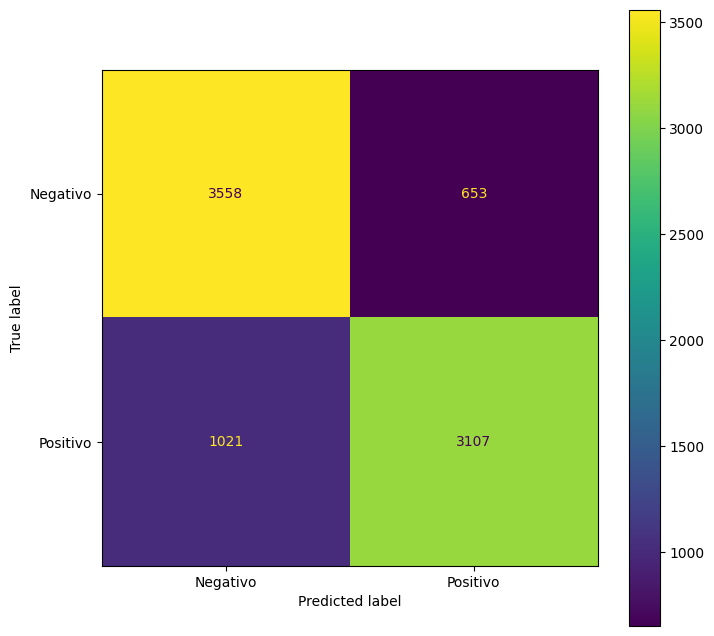

Accuracy: 0.80
F1 Score: 0.79


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# Obtener las predicciones del modelo sobre el conjunto de prueba
predictions = model.predict(test_padded)
predicted_labels = (predictions > 0.5).astype(int).flatten()

# Calcular la accuracy
accuracy = accuracy_score(test_labels, predicted_labels)

# Calcular el F1 score
f1 = f1_score(test_labels, predicted_labels)

# Crear la matriz de confusión
cm = confusion_matrix(test_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])

# Graficar la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)
plt.show()

# Mostrar la accuracy y el F1 score
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")

261/261 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step


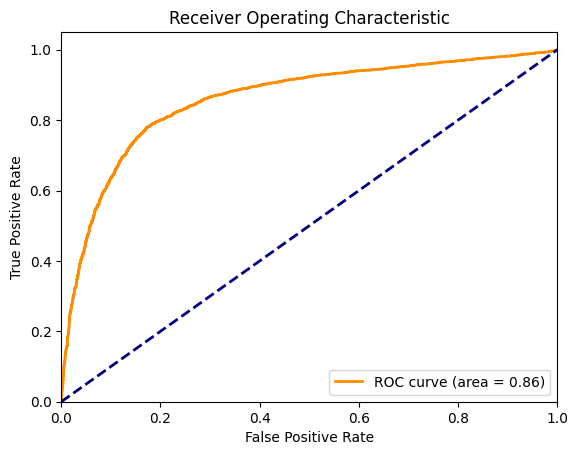

AUC: 0.86


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtener las probabilidades de las predicciones
y_prob = model.predict(test_padded).ravel()

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(test_labels, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

print(f"AUC: {roc_auc:.2f}")

261/261 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step


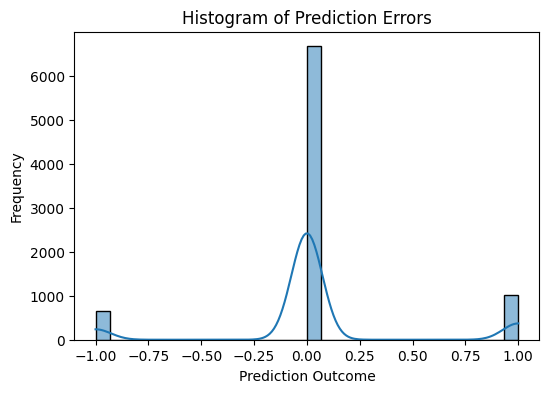

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener las predicciones del modelo
y_pred = (model.predict(test_padded) > 0.5).astype("int32")

# Calcular los errores como la diferencia entre las etiquetas verdaderas y las predicciones
errors = np.array(test_labels) - np.array(y_pred).flatten()

# Crear el histograma de errores con barras más delgadas
plt.figure(figsize=(6, 4))
sns.histplot(errors, kde=True, bins=30)
plt.xlabel('Prediction Outcome')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Errors')
plt.show()